In [21]:
df.to_csv('data.csv')

In [22]:
import pandas as pd

df = pd.read_csv("data.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

ts_data = df[['voice_calls', 'chats', 'emails', 'tickets']]

In [23]:
train_size = int(len(ts_data) * 0.8)

train = ts_data[:train_size]
test = ts_data[train_size:]

In [24]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):
    result = adfuller(series)
    print(f"{name}: p-value = {result[1]}")

for col in train.columns:
    adf_test(train[col], col)

voice_calls: p-value = 1.3034587319731619e-27
chats: p-value = 8.822809921169694e-29
emails: p-value = 1.8041032053481805e-29
tickets: p-value = 6.945862937361168e-30


In [26]:
from statsmodels.tsa.api import VAR

model = VAR(train)

In [27]:
lag_order_results = model.select_order(maxlags=24)
print(lag_order_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        14.33       14.33   1.673e+06       14.33
1        11.77       11.79   1.298e+05       11.78
2        11.55       11.59   1.043e+05       11.57
3        11.42       11.47   9.082e+04       11.43
4        11.28       11.34   7.889e+04       11.30
5        11.17       11.25   7.085e+04       11.20
6        11.10       11.19   6.587e+04       11.13
7        11.06       11.18   6.370e+04       11.10
8        11.05       11.18   6.278e+04       11.09
9        11.02       11.17   6.118e+04       11.07
10       10.96       11.12   5.770e+04       11.02
11       10.90       11.07   5.392e+04       10.96
12       10.85       11.04   5.166e+04       10.92
13       10.81       11.02   4.945e+04       10.88
14       10.77       10.99   4.734e+04       10.84
15       10.74       10.98   4.617e+04       10.82
16       10.72      10.98*   4.

In [28]:
var_model = model.fit(24)
print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 25, Apr, 2026
Time:                     11:41:36
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    10.9913
Nobs:                     6984.00    HQIC:                   10.7419
Log likelihood:          -76304.1    FPE:                    40567.6
AIC:                      10.6107    Det(Omega_mle):         38389.9
--------------------------------------------------------------------
Results for equation voice_calls
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.738664         0.418094            1.767           0.077
L1.voice_calls          0.240772         0.012232           19.684           0.000
L1.chats                0.092100         0.014

In [29]:
forecast_input = train.values[-24:]

forecast = var_model.forecast(y=forecast_input, steps=len(test))

forecast_df = pd.DataFrame(
    forecast,
    index=test.index,
    columns=test.columns
)

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['voice_calls'], forecast_df['voice_calls'])
rmse = np.sqrt(mean_squared_error(test['voice_calls'], forecast_df['voice_calls']))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 9.863375615255237
RMSE: 12.119059883107077


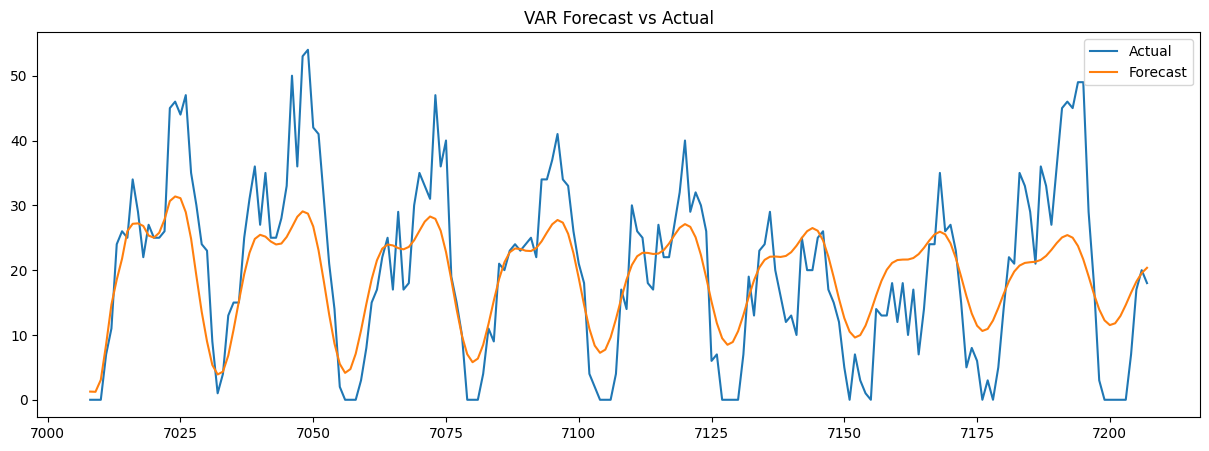

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(test.index[:200], test['voice_calls'][:200], label='Actual')
plt.plot(test.index[:200], forecast_df['voice_calls'][:200], label='Forecast')
plt.legend()
plt.title("VAR Forecast vs Actual")
plt.show()

In [32]:
mae = mean_absolute_error(test['voice_calls'], forecast_df['voice_calls'])
rmse = np.sqrt(mean_squared_error(test['voice_calls'], forecast_df['voice_calls']))

mape = np.mean(np.abs((test['voice_calls'] - forecast_df['voice_calls']) / test['voice_calls'].replace(0,1))) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 9.863375615255237
RMSE: 12.119059883107077
MAPE: 294.09719789943443
